# Classification Trees — LOOCV (Final)

Decision-tree models for the presence/absence of *Perlidae* and *Helicopsychidae*,
evaluated with leave-one-out cross-validation (LOOCV, n = 18) so they are comparable
with the logistic and fuzzy models.

## 1. Introduction

Decision-tree models for the presence/absence of *Perlidae* and *Helicopsychidae*
are evaluated with full leave-one-out cross-validation (LOOCV, n = 18). Depth-3
trees with balanced class weights are used throughout the LOOCV evaluation. Both
calibration (aggregated training-fold) and validation (held-out) metrics are
reported. A representative tree trained on the modal fold — the fold whose selected
predictor set occurs most frequently across all LOOCV folds — is shown for
structural interpretation.

## 2. Dependencies and Data Loading

The macroinvertebrate dataset (n = 18) provides the seven physicochemical predictors
and the binary presence/absence of `Perlidae` and `Trichoptera` (Helicopsychidae).

In [12]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as spstats
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (classification_report, confusion_matrix, cohen_kappa_score,
                             accuracy_score, precision_recall_fscore_support)
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [13]:
# Load the macroinvertebrate dataset (relative path)
df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
print("Perlidae +/-:", df['Perlidae'].value_counts().to_dict())
print("Helicopsychidae (Trichoptera) +/-:", df['Trichoptera'].value_counts().to_dict())

Shape: (18, 24)
Perlidae +/-: {0: 12, 1: 6}
Helicopsychidae (Trichoptera) +/-: {0: 15, 1: 3}


## 3. Predictor Candidates

The seven physicochemical predictors — `COT`, `DBO5`, `Dureza`, `Magnesio`,
`Turbiedad`, `OD`, and `Caudal` — form the candidate pool. The actual subset used
in each LOOCV fold is chosen **inside each fold** via Spearman rank correlation (ρₛ)
computed on the n−1 = 17 training observations only (see Section 4). Trees are
limited to `max_depth=3` for ecological and methodological reasons documented in
Section 4.

**Why Spearman rank correlation for predictor screening**

Physicochemical variables in tropical river systems characteristically exhibit
skewed, non-normal distributions driven by seasonal flood pulses, episodic
anthropogenic inputs, and geochemical heterogeneity (Zuur et al., 2009). Spearman
rank correlation (ρₛ) quantifies monotonic association by operating on ranks rather
than raw values, requiring neither normality nor linearity and remaining robust to
the heavy tails and occasional extreme observations typical of field-collected
hydrochemical data (Zuur et al., 2009; Legendre & Legendre, 2012). With only 17
training observations per LOOCV fold, parametric model-selection criteria such as
AIC computed from binomial GLMs risk convergence failures, quasi-perfect separation,
and inflated estimates. Spearman screening avoids these pathologies by operating
pairwise and without model fitting, providing greater numerical stability under small
samples.

**References**

- Legendre, P. & Legendre, L. (2012). *Numerical Ecology* (3rd ed.). Elsevier.
- Zuur, A. F., Ieno, E. N., Walker, N., Saveliev, A. A. & Smith, G. M. (2009).
  *Mixed Effects Models and Extensions in Ecology with R*. Springer.

In [14]:
# Seven physicochemical predictors and their English display names
predictor_cols = ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']
feature_names_en = ['TOC', 'BOD5', 'Hardness', 'Magnesium', 'Turbidity', 'DO', 'Flowrate']
print("Predictors:", predictor_cols)

Predictors: ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']


## 4. Model Definition

A depth-3 `DecisionTreeClassifier` with `class_weight='balanced'` counters class
imbalance (Perlidae 6/18 present; Helicopsychidae 3/18 present). Both settings are
ecological and domain choices that are **not tuned** across folds.

**Nested predictor selection (per fold).** Before fitting the tree in each LOOCV
fold, Spearman rank correlations (|ρₛ|) are computed between each of the 7 candidate
predictors and the target variable using only the 17 training observations of that
fold. The top-3 predictors by |ρₛ| are retained. The fixed value of k=3 follows
directly from the max_depth=3 architectural constraint: a tree of depth 3 has at
most 3 internal decision nodes, each of which can split on a different predictor.
Including more than 3 predictors would introduce variables that the tree structure
cannot use; including fewer would artificially restrict the predictor space below
what the architecture supports. This is a structural constraint, not a data-driven
regularisation choice (Breiman et al., 1984; Strobl et al., 2009).

**Why max_depth=3.** Shallow trees are recommended for small ecological datasets on
two grounds. First, interpretability: ecologists can read and communicate a 3-level
decision rule linking physicochemical thresholds to taxon presence; deeper trees
produce splitting rules that are difficult to relate to underlying ecological processes
(Breiman et al., 1984). Second, parsimony: with n = 18 observations, a deeper tree
rapidly approaches the size of the training set and memorises noise rather than
capturing structure; depth-3 limits the maximum number of leaves to 8, keeping the
effective predictor-to-observation ratio within a range that allows generalisation to
new sites (Strobl et al., 2009).

**References**

- Breiman, L., Friedman, J. H., Olshen, R. A. & Stone, C. J. (1984). *Classification
  and Regression Trees*. Wadsworth.
- Legendre, P. & Legendre, L. (2012). *Numerical Ecology* (3rd ed.). Elsevier.
- Strobl, C., Malley, J. & Tutz, G. (2009). An introduction to recursive
  partitioning: rationale, application, and characteristics of classification and
  regression trees, bagging, and random forests. *Psychological Methods*, 14(4),
  323–348.
- Zuur, A. F., Ieno, E. N., Walker, N., Saveliev, A. A. & Smith, G. M. (2009).
  *Mixed Effects Models and Extensions in Ecology with R*. Springer.

In [ ]:
# LOOCV routine with nested Spearman predictor selection inside each fold
def tree_loocv(y_col):
    X = df[predictor_cols]
    y = df[y_col]
    loo = LeaveOneOut()
    yt_val, yp_val, yt_cal, yp_cal = [], [], [], []
    fold_selected = []
    for tr, te in loo.split(X):
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        # Spearman |rs| computed on training observations only; always top-3
        rs_abs = [abs(spstats.spearmanr(X_tr[col], y_tr).statistic) for col in predictor_cols]
        ranked = sorted(range(len(predictor_cols)), key=lambda i: rs_abs[i], reverse=True)
        sel_cols = [predictor_cols[i] for i in ranked[:3]]
        fold_selected.append(sel_cols)
        clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
        clf.fit(X_tr[sel_cols], y_tr)
        yt_val.append(int(y.iloc[te].iloc[0]))
        yp_val.append(int(clf.predict(X.iloc[te][sel_cols])[0]))
        yt_cal.extend(y_tr.tolist())
        yp_cal.extend(clf.predict(X_tr[sel_cols]).tolist())
    return {'yt_val': yt_val, 'yp_val': yp_val,
            'yt_cal': yt_cal, 'yp_cal': yp_cal,
            'fold_selected': fold_selected}

# Standardised confusion-matrix plotter: figsize (10, 7), Blues, saved to outputs/ and shown
def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 16},
                xticklabels=['Absent', 'Present'], yticklabels=['Absent', 'Present'])
    plt.title(title, fontsize=14); plt.xlabel('Predicted', fontsize=12); plt.ylabel('Observed', fontsize=12)
    plt.tight_layout(); plt.savefig(f"../../outputs/{filename}", dpi=300); plt.show()

# Fit LOOCV for both taxa
loocv = {'Perlidae': tree_loocv('Perlidae'),
         'Helicopsychidae': tree_loocv('Trichoptera')}
print("LOOCV complete for both taxa.")

## 5. Evaluation — Calibration

Calibration confusion matrices aggregate the training-fold predictions across all
LOOCV folds (18 folds × 17 training rows).

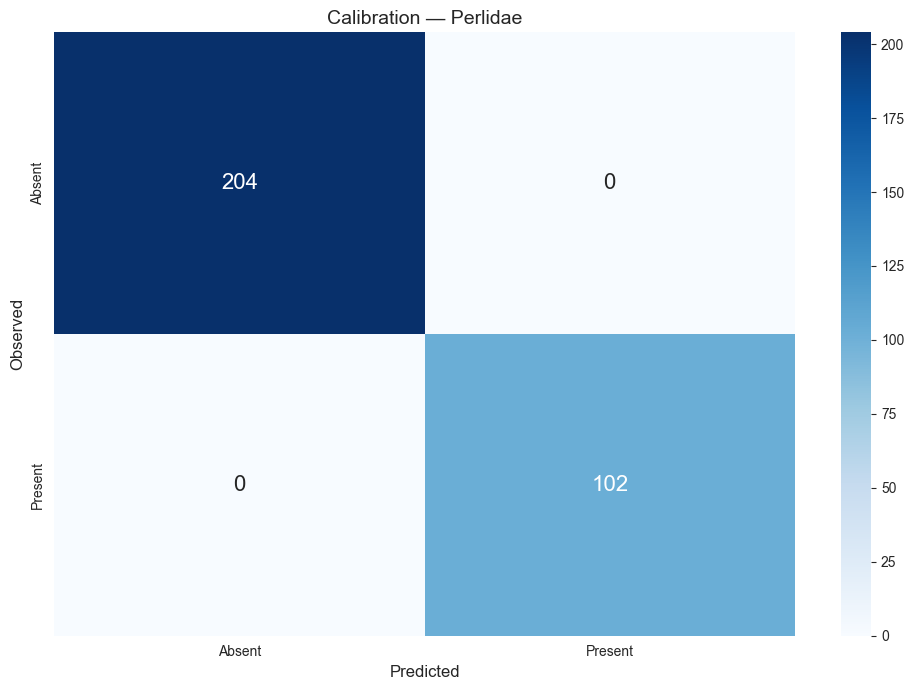

              precision    recall  f1-score   support

      Absent       1.00      1.00      1.00       204
     Present       1.00      1.00      1.00       102

    accuracy                           1.00       306
   macro avg       1.00      1.00      1.00       306
weighted avg       1.00      1.00      1.00       306

Cohen's Kappa (calibration): 1.000


In [16]:
# Perlidae — calibration confusion matrix, classification report, Cohen's kappa
res = loocv['Perlidae']
plot_confusion(res['yt_cal'], res['yp_cal'], 'Calibration — Perlidae',
               'trees_perlidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

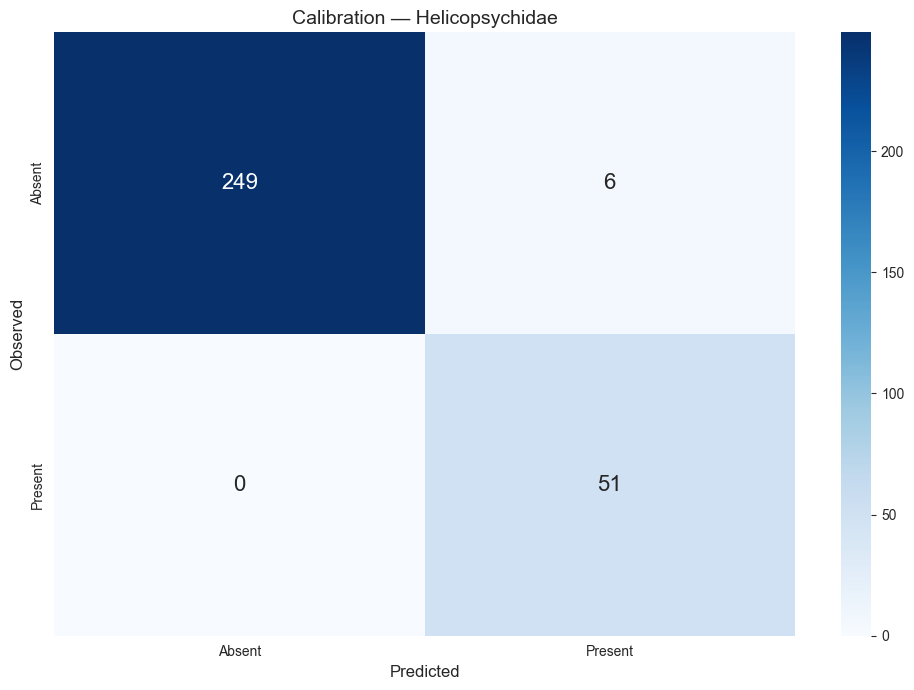

              precision    recall  f1-score   support

      Absent       1.00      0.98      0.99       255
     Present       0.89      1.00      0.94        51

    accuracy                           0.98       306
   macro avg       0.95      0.99      0.97       306
weighted avg       0.98      0.98      0.98       306

Cohen's Kappa (calibration): 0.933


In [17]:
# Helicopsychidae — calibration confusion matrix, classification report, Cohen's kappa
res = loocv['Helicopsychidae']
plot_confusion(res['yt_cal'], res['yp_cal'], 'Calibration — Helicopsychidae',
               'trees_helicopsychidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

## 6. Evaluation — Validation (LOOCV)

Validation metrics use the held-out observation from each fold — the honest estimate
of out-of-sample performance. Each prediction is produced by a model that has never
seen the held-out observation, neither for fitting nor for predictor selection.

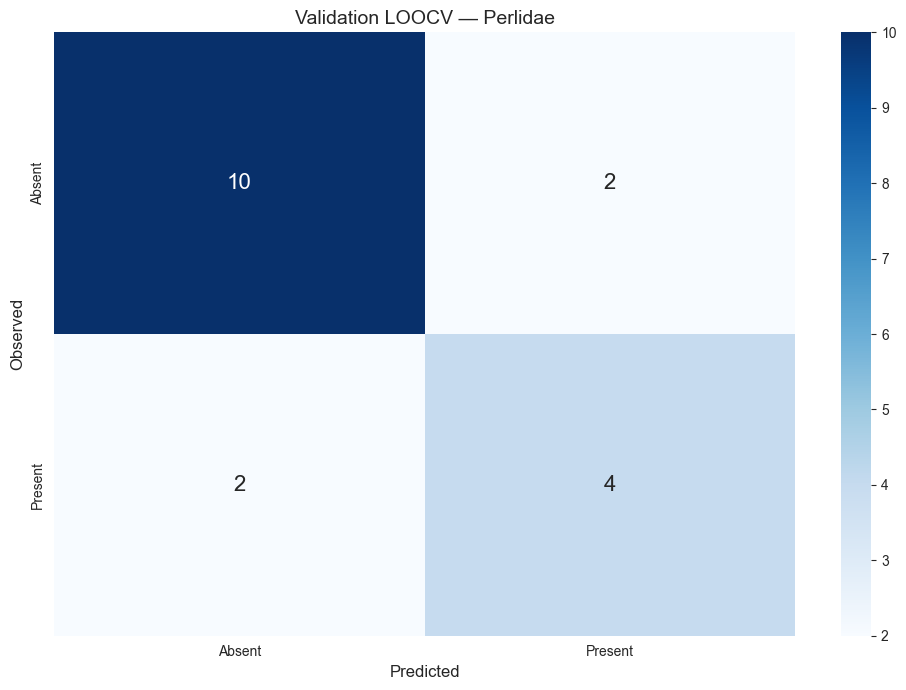

              precision    recall  f1-score   support

      Absent       0.83      0.83      0.83        12
     Present       0.67      0.67      0.67         6

    accuracy                           0.78        18
   macro avg       0.75      0.75      0.75        18
weighted avg       0.78      0.78      0.78        18

Cohen's Kappa (validation): 0.500


In [18]:
# Perlidae — validation confusion matrix, classification report, Cohen's kappa
res = loocv['Perlidae']
plot_confusion(res['yt_val'], res['yp_val'], 'Validation LOOCV — Perlidae',
               'trees_perlidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

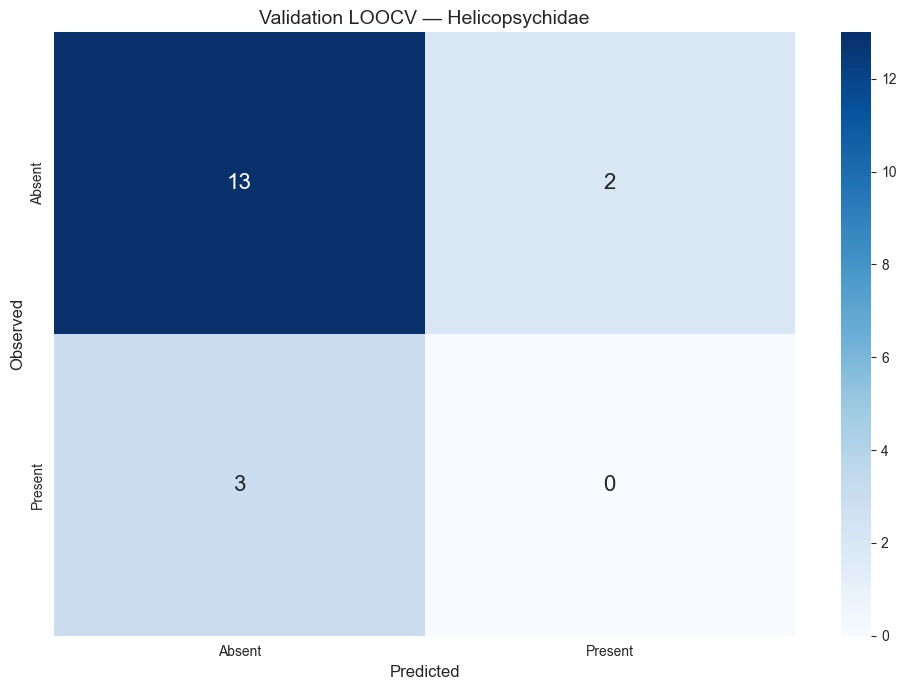

              precision    recall  f1-score   support

      Absent       0.81      0.87      0.84        15
     Present       0.00      0.00      0.00         3

    accuracy                           0.72        18
   macro avg       0.41      0.43      0.42        18
weighted avg       0.68      0.72      0.70        18

Cohen's Kappa (validation): -0.154


In [19]:
# Helicopsychidae — validation confusion matrix, classification report, Cohen's kappa
res = loocv['Helicopsychidae']
plot_confusion(res['yt_val'], res['yp_val'], 'Validation LOOCV — Helicopsychidae',
               'trees_helicopsychidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

## 7. Predictor Stability

Because the Spearman-based selection runs independently inside each of the 18 LOOCV
folds, the chosen predictors can differ across folds. The table below counts how many
times (out of 18) each candidate was selected for each taxon, revealing which predictors
are most consistently informative on this small dataset.

In [20]:
# Predictor stability: count folds selected for each taxon
def stability_counts(fold_selected):
    counts = {p: 0 for p in predictor_cols}
    for sel in fold_selected:
        for p in sel:
            counts[p] += 1
    return counts

per_counts = stability_counts(loocv['Perlidae']['fold_selected'])
hel_counts = stability_counts(loocv['Helicopsychidae']['fold_selected'])

stab_df = pd.DataFrame({
    'predictor': predictor_cols,
    'perlidae_folds_selected': [per_counts[p] for p in predictor_cols],
    'helicopsychidae_folds_selected': [hel_counts[p] for p in predictor_cols],
})
stab_df = stab_df.sort_values('perlidae_folds_selected', ascending=False).reset_index(drop=True)
print("Predictor stability (folds selected out of 18):")
print(stab_df.to_string(index=False))
print()
print(f"Most selected — Perlidae:        {max(per_counts, key=per_counts.get)} ({max(per_counts.values())}/18 folds)")
print(f"Most selected — Helicopsychidae: {max(hel_counts, key=hel_counts.get)} ({max(hel_counts.values())}/18 folds)")

# Save stability CSV
stab_df.to_csv("../../outputs/metrics_trees_predictor_stability.csv", index=False)
print("\nSaved outputs/metrics_trees_predictor_stability.csv")

Predictor stability (folds selected out of 18):
predictor  perlidae_folds_selected  helicopsychidae_folds_selected
     DBO5                       18                              13
   Dureza                       18                               1
Turbiedad                       18                               0
      COT                        0                               1
 Magnesio                        0                               0
       OD                        0                               8
   Caudal                        0                              18

Most selected — Perlidae:        DBO5 (18/18 folds)
Most selected — Helicopsychidae: Caudal (18/18 folds)

Saved outputs/metrics_trees_predictor_stability.csv


## 8. Visualisation: Modal-Fold Decision Trees

For structural interpretation, a representative decision tree is shown for each
taxon. This tree is trained on the n−1 = 17 observations of the **modal fold**: the
fold whose selected predictor set matches the most frequently occurring predictor
combination across all 18 LOOCV folds. The modal fold therefore represents the
typical model structure encountered during cross-validation. The tree is trained
without `class_weight='balanced'` so that raw class proportions determine node
colours; every node carries an explicit filled colour (orange = majority absent,
blue = majority present, intermediate shades = mixed class distribution).

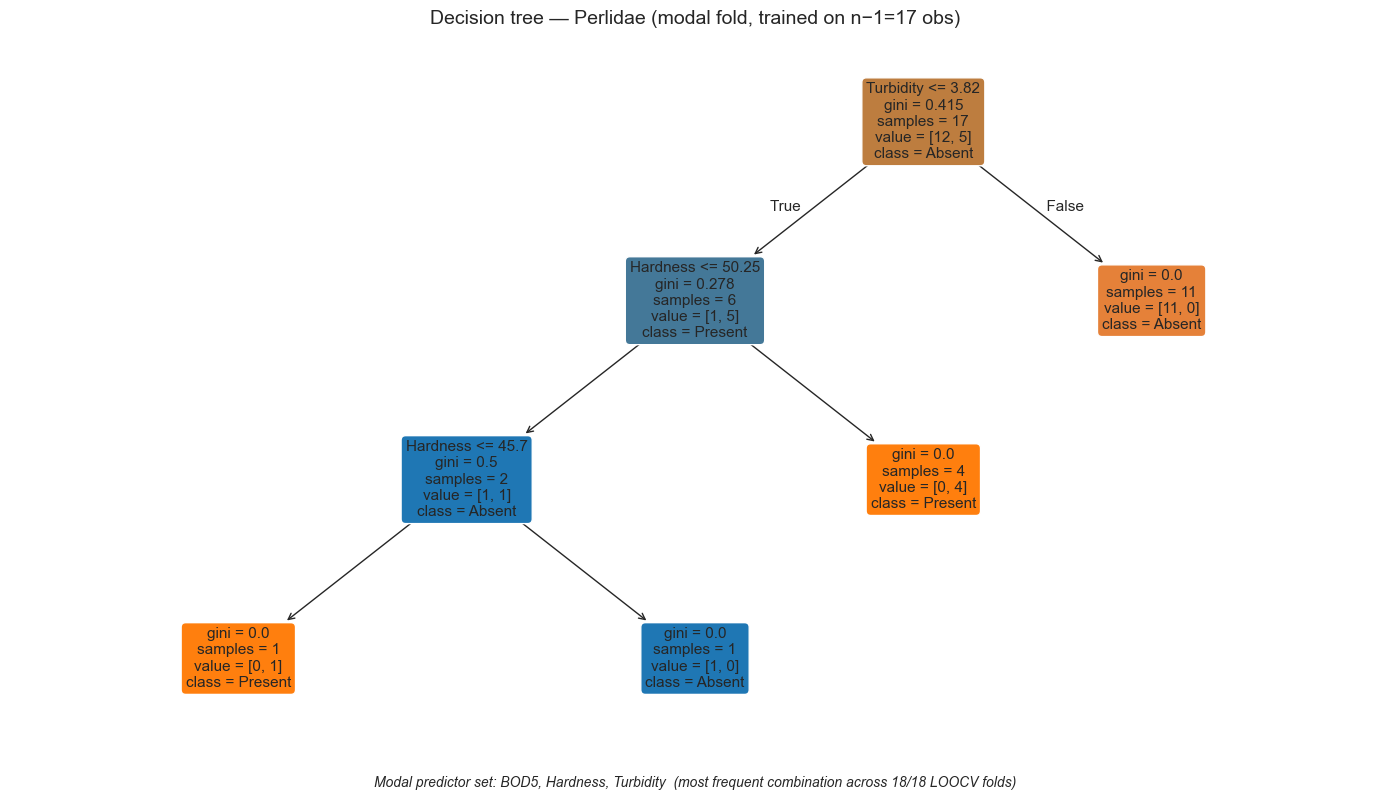

Saved tree_modal_perlidae.png  |  predictors: ['DBO5', 'Dureza', 'Turbiedad']  |  depth=3, leaves=4


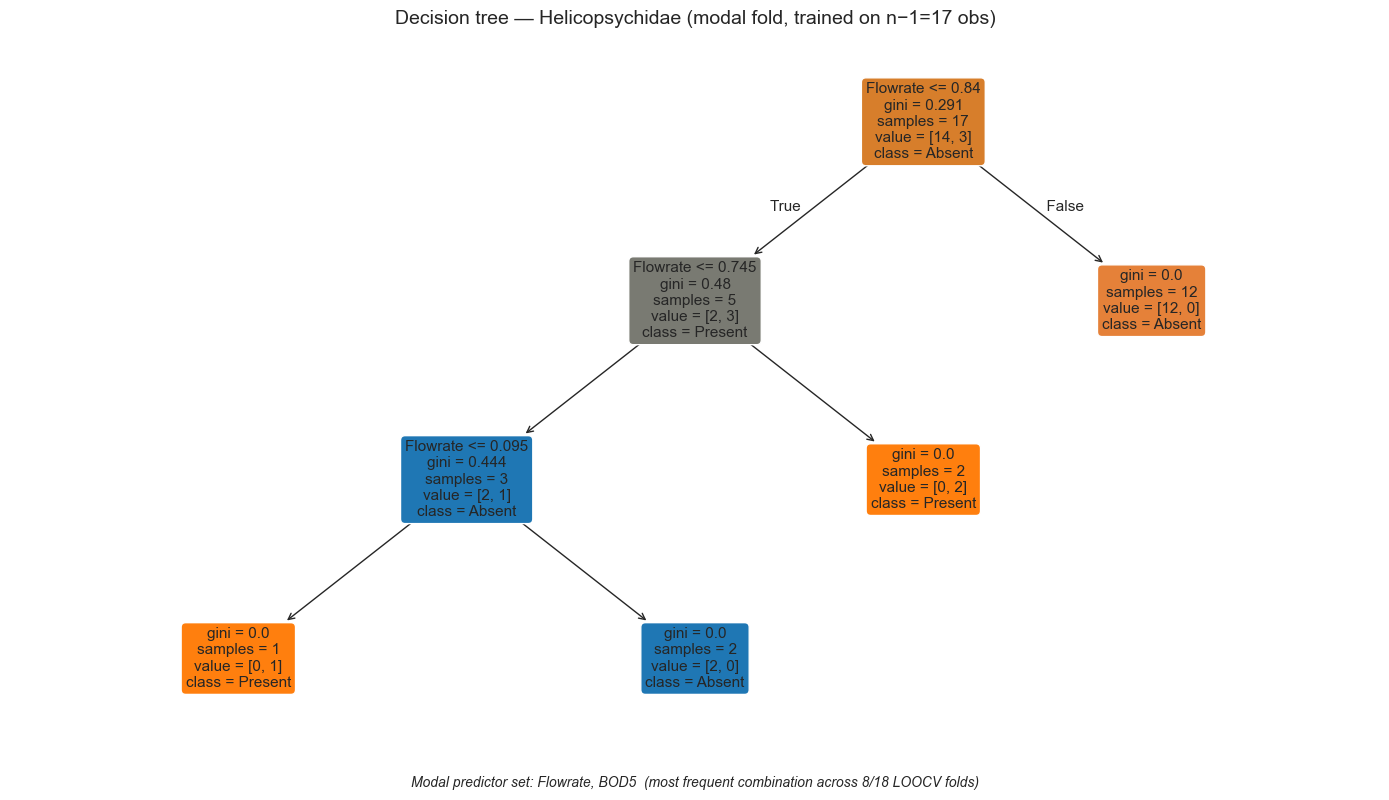

Saved tree_modal_helicopsychidae.png  |  predictors: ['Caudal', 'DBO5']  |  depth=3, leaves=4


In [21]:
import matplotlib.colors as mcolors
from collections import Counter as _Counter

pred_to_en = dict(zip(predictor_cols, feature_names_en))

def _apply_custom_colors(artists, clf):
    """Override fill colour for every node: absent=orange, present=blue, mixed=blend.
    No node is left white regardless of class balance in the training fold."""
    values = clf.tree_.value.squeeze(axis=1)  # shape [n_nodes, n_classes]
    c_absent  = np.array(mcolors.to_rgb('#ff7f0e'))   # orange  → absent
    c_present = np.array(mcolors.to_rgb('#1f77b4'))   # blue    → present

    # Build preorder (root, left subtree, right subtree) to match plot_tree's
    # rendering order, which visits nodes before recursing into children.
    LEAF = -1
    tree_ = clf.tree_
    def _preorder(nid, out):
        out.append(nid)
        if tree_.children_left[nid] != LEAF:
            _preorder(tree_.children_left[nid], out)
            _preorder(tree_.children_right[nid], out)
    node_order = []
    _preorder(0, node_order)

    for rank, nid in enumerate(node_order):
        if rank >= len(artists):
            break
        v = values[nid]
        total = v.sum()
        if total == 0:
            continue
        prop_present = v[1] / total
        color = (1.0 - prop_present) * c_absent + prop_present * c_present
        bbox = artists[rank].get_bbox_patch()
        if bbox is not None:
            bbox.set_facecolor(color)
            bbox.set_alpha(1.0)

def plot_modal_tree(loocv_key, y_col, filename):
    fold_selected = loocv[loocv_key]['fold_selected']
    combos = [frozenset(s) for s in fold_selected]
    modal_combo, modal_count = _Counter(combos).most_common(1)[0]
    modal_fold_idx = next(i for i, s in enumerate(fold_selected)
                          if frozenset(s) == modal_combo)

    sel_cols   = sorted(modal_combo)
    feat_names = [pred_to_en[c] for c in sel_cols]
    all_idx    = np.arange(len(df))
    tr_idx     = np.delete(all_idx, modal_fold_idx)
    train_data = df.iloc[tr_idx]

    # Train without class_weight so raw proportions determine node colours
    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf.fit(train_data[sel_cols], train_data[y_col])

    fig, ax = plt.subplots(figsize=(14, 8))
    artists = plot_tree(clf, feature_names=feat_names,
                        class_names=['Absent', 'Present'],
                        filled=True, rounded=True, fontsize=11, ax=ax)
    _apply_custom_colors(artists, clf)

    title = f'Decision tree — {loocv_key} (modal fold, trained on n−1=17 obs)'
    ax.set_title(title, fontsize=14)
    caption = (f'Modal predictor set: {", ".join(feat_names)}  '
               f'(most frequent combination across {modal_count}/18 LOOCV folds)')
    fig.text(0.5, 0.01, caption, ha='center', fontsize=10, style='italic')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(f"../../outputs/{filename}", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved {filename}  |  predictors: {sel_cols}  "
          f"|  depth={clf.get_depth()}, leaves={clf.get_n_leaves()}")

plot_modal_tree('Perlidae',        'Perlidae',    'tree_modal_perlidae.png')
plot_modal_tree('Helicopsychidae', 'Trichoptera', 'tree_modal_helicopsychidae.png')

In [22]:
# Export validation metrics for the master results table
rows = []
for taxon in ['Perlidae', 'Helicopsychidae']:
    res = loocv[taxon]
    p, r, f, _ = precision_recall_fscore_support(res['yt_val'], res['yp_val'], labels=[0, 1],
                                                 average='macro', zero_division=0)
    rows.append({'target': taxon, 'technique': 'Classification trees', 'validation': 'LOOCV', 'n': 18,
                 'precision': round(p, 3), 'recall': round(r, 3), 'f1': round(f, 3),
                 'accuracy': round(accuracy_score(res['yt_val'], res['yp_val']), 3),
                 'kappa': round(cohen_kappa_score(res['yt_val'], res['yp_val']), 3)})
pd.DataFrame(rows).to_csv("../../outputs/metrics_trees.csv", index=False)
print("Saved outputs/metrics_trees.csv")
print(pd.DataFrame(rows).to_string(index=False))

Saved outputs/metrics_trees.csv
         target            technique validation  n  precision  recall    f1  accuracy  kappa
       Perlidae Classification trees      LOOCV 18      0.750   0.750 0.750     0.778  0.500
Helicopsychidae Classification trees      LOOCV 18      0.406   0.433 0.419     0.722 -0.154


## 9. Limitations

- **Very small sample** (n = 18) with class imbalance; depth-3 trees fit the
  17-row training folds almost perfectly (high calibration accuracy), so the gap
  between calibration and validation reflects overfitting rather than genuine skill.
- **Instability.** With so few observations the chosen split variables — and the
  Spearman-selected predictor subset — can change from fold to fold; the modal-fold
  diagram (Section 8) illustrates the most frequently occurring model structure and
  does not represent every fold.
- **Predictor selection variability.** Because selection is re-run on 17 observations
  per fold, borderline predictors may enter or leave the active set, contributing to
  the instability shown in Section 7.
- **Spatial non-independence.** Stations lie along one river reach, so LOOCV folds
  are not fully independent; effective sample size is lower than n = 18.
- **Rare taxon.** For Helicopsychidae (3/18 present) high overall accuracy is largely
  driven by the majority (absent) class; Cohen's κ is the more informative summary.